# MACE in Practice II

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ddmms/camml-tutorials/blob/main/notebooks/07-mlips/T02_MACE_Practice_II.ipynb)

In this tutorial, you will learn how to improve MLIP models by using iterative training and active learning. We illustrate these training workflows on MACE, but they are broadly applicable to all MLIPs. We will also showcase the state-of-the-art [foundational models](https://matbench-discovery.materialsproject.org/) - the latest development in the field of MLIPs. These models are trained on massive training sets of [inorganic](https://doi.org/10.48550/arXiv.2401.00096) and [organic](https://doi.org/10.48550/arXiv.2312.15211) databases and show a great deal of `out-of-the-box` MD stability in an extensive variety of [applications](https://doi.org/10.48550/arXiv.2401.00096). We will discuss [fine-tunning](https://doi.org/10.48550/arXiv.2405.20217) which is an actively-researched technique to tweak these foundational models to new systems (out of training) and/or new levels of reference theory.

## Learning Objectives for today:

1. **Iterative Training: improving stability and accuracy**
2. **Active learning: committee models**
3. **Foundational models and fine-tuning**

## Setup(optional)

The next cell needs to be run only if you use google colab. Commands may work in other environments too but are not tested.

In [ ]:
# ### only if you are in google colab

# import locale
# locale.getpreferredencoding = lambda: "UTF-8"

# ! uv pip install mace-torch data-tutorials weas_widget tblite rdkit  --system
# get_ipython().kernel.do_shutdown(restart=True)

# ! pip install git+https://github.com/imagdau/aseMolec@main

Here we will install our dataset

In [ ]:
from data_tutorials.data import get_data

get_data(
    url="https://raw.githubusercontent.com/ccp5UK/summerschool/main/Day_9ML/data/",
    filename=["solvent_configs.xyz",  "solvent_liquid.xyz",  "solvent_molecs.xyz", "solvent_xtb.xyz"],
    folder="data",
)

## 1. Iterative Training

### 1.1 MD with a smaller MACE model

The model we trained in our previous tutorial was already stable in MD and quite accurate with little training. This is both because MACE models are smooth and very accurate but also because the task of simulating a single molecule for a few picoseconds is not all that difficult. In general, in real research applications, achieving MD stability and accuracy is not always straightforward from the get-go. Models can be improved through iterative training and active learning which expands the training data to fix errors on the model's potential energy surface.

In this application, we will develop an MLIP for molecular liquids of carbonates. The data presented here is a subset from [this work](https://doi.org/10.1021/acs.jpcb.2c03746) and comprises a mixture of 6 different types of molecules: cyclic carbonates (Vinylene carbonate VC, Ethylene carbonate EC, Propylene carbonate PC) and linear carbonates (Dimethyl carbonate DMC, Ethyl Methyl Carbonate EMC, Diethyl carbonate DEC). Mixtures of these molecules in various formulations are used as solvents in Li-ion battery electrolytes. Let's start by visualising our dataset. 

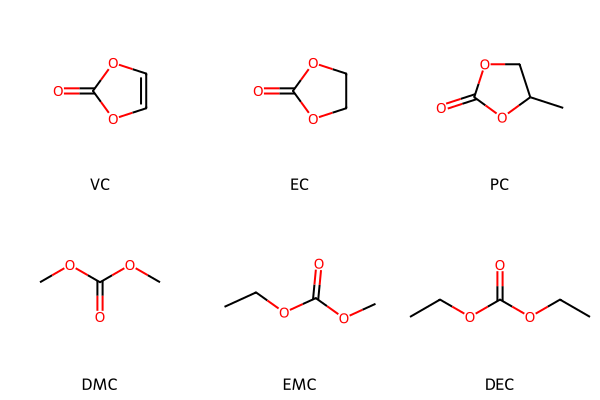

In [3]:
from rdkit import Chem
from rdkit.Chem import Draw

# choose your device here.
#device = 'cpu'
device =  'cuda'

# SMILES strings for each molecule
sm_dict = {
    'VC': 'c1coc(=O)o1',
    'EC': 'C1COC(=O)O1',
    'PC': 'CC1COC(=O)O1',
    'DMC': 'COC(=O)OC',
    'EMC': 'CCOC(=O)OC',
    'DEC': 'CCOC(=O)OCC'
}

Draw.MolsToGridImage([Chem.MolFromSmiles(sm_dict[mol]) for mol in sm_dict], legends=list(sm_dict.keys()))

For this tutorial, we prepared in advance a collection of atomic configurations (small subset from [this paper](https://doi.org/10.1021/acs.jpcb.2c03746)). Let's understand the data!

In [ ]:
from ase.io import read, write
from weas_widget import WeasWidget

import numpy as np

db = read('data/solvent_configs.xyz', ':') #read in list of configs

print("Number of configs in database: ", len(db))
print("Number of atoms in each config: ", np.array([len(at) for at in db]))
print("Number of atoms in the smallest config: ", np.min([len(at) for at in db])) #test if database contains isolated atoms
print("Information stored in config.info: \n", db[10].info) #check info
print("Information stored in config.arrays: \n", db[10].arrays)

Number of configs in database:  5000
Number of atoms in each config:  [24 22 25 ... 25 32 40]
Number of atoms in the smallest config:  8
Information stored in config.info: 
 {'Nmols': 2, 'Comp': 'DEC(1):EC(1)'}
Information stored in config.arrays: 
 {'numbers': array([6, 8, 6, 8, 6, 1, 1, 8, 1, 1, 6, 8, 8, 8, 6, 6, 6, 1, 1, 6, 1, 1,
       1, 1, 1, 1, 1, 1]), 'positions': array([[ 2.42930269,  5.21925545, -2.44555688],
       [ 1.36888075,  4.36736107, -3.07848001],
       [ 1.0430907 ,  3.33270121, -2.205446  ],
       [ 1.83499873,  3.2705152 , -1.20140588],
       [ 2.83662271,  4.2916441 , -1.29654086],
       [ 3.20092463,  5.52685308, -3.12019396],
       [ 1.98896468,  6.07220507, -2.07261896],
       [ 0.15712669,  2.55914021, -2.58440089],
       [ 3.80655074,  3.73805737, -1.62337792],
       [ 3.03487277,  4.82053137, -0.40139091],
       [-1.35643137, -2.96665978,  1.35700715],
       [-1.21188033, -2.7462728 ,  0.1501831 ],
       [-0.54117233, -3.68505168,  2.08627701],
 

We can visualize the databse using the WEAS pyhon library, or locally we can use a standalone software like `ovito` to view the `*.xyz` files directly. You can launch the `Desktop` application for `ovito` from the `Launcher` and navigate to your working directory in the terminal, then simply run `ovito <filename>.xyz`.

In [8]:
import ipywidgets as widgets
from weas_widget import WeasWidget
from IPython.display import display, HTML


# Function to display a molecule
def display_molecule(atoms):
    viewer = WeasWidget()
    viewer.from_ase(atoms)
    display(viewer)

viewers = []
for atoms in db[:10]: #display the first 10 configurations
    viewer = WeasWidget()
    viewer.from_ase(atoms)
    viewer.avr.model_style = 0
    viewer.avr.show_hydrogen_bonds = False
    viewers.append(viewer)

left_column = widgets.VBox(viewers[::2])  # Even-indexed viewers
right_column = widgets.VBox(viewers[1::2])  # Odd-indexed viewers

display(widgets.HBox([left_column, right_column]))

Note the additional information for each atomic config: number of molecules `Nmols`, molecular composition `Comp` (e.g `DEC(1):EC(1)` means the config comprises a dimer with 1 DEC molecule and 1 EC molecule) and molecular ID `molID`. Running the code for the full 5000 configurations can be slow, let's just load the final result (`data/solvent_molecs.xyz`) and inspect the distribution of configs by number of molecules:

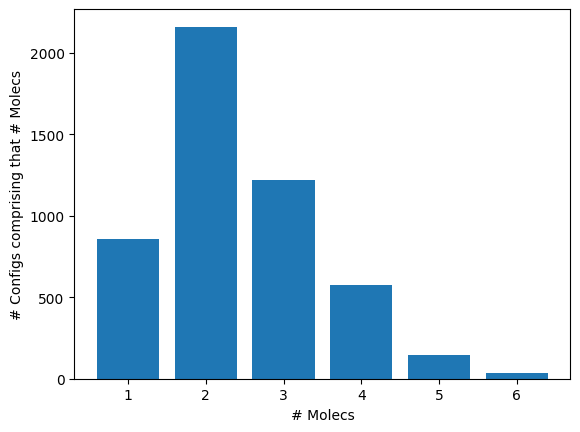

In [9]:
from matplotlib import pyplot as plt

db = read('data/solvent_molecs.xyz', ':')
Nmols = np.array([at.info['Nmols'] for at in db]) #collect Nmols information across all data
plt.hist(Nmols, align='left', bins=[1,2,3,4,5,6,7], rwidth=0.8);
plt.xlabel('# Molecs');
plt.ylabel('# Configs comprising that # Molecs');

There are just under 1000 configs comprising of single molecules and more than 2000 dimers. The largest configs contain clusters of six molecules.

We can check the distribution of molecular compositions for each cluster size:

In [ ]:
from aseMolec import extAtoms as ea
from collections import Counter

comp_dict = {} #create a dictionary of compositions for each cluster size
for Nmol in range(1,7):
    comp_dict[Nmol] = dict(Counter([at.info['Comp'] for at in ea.sel_by_info_val(db, 'Nmols', Nmol)]))

Nmol = 6 #show distribution of compositions for cluster size 6
plt.pie(comp_dict[Nmol].values(),
        labels=comp_dict[Nmol].keys(),
        explode=10/(25+np.array(list(comp_dict[Nmol].values()))),
        rotatelabels =True);

**Task for you**
<div class="alert alert-block alert-info">

The training set is quite diverse and it contains a good mix of compositions. Check the distribution for other cluster sizes: `Nmol = 1, 2, 3, 4, 5`. Find out if all isolated molecules are present and well sampled. We have six molecules, so there should be 6x7/2 dimers present, are all dimers sampled?
</div>

**To illustrate these concepts in practice, let's first train a less accurate MACE by reducing a lot the model size and amount of training data: we will make a model with just 20 training configurations. Note that a larger model would probably work out of the box for this example. We will also make a test set of the final 500 configs**

In [39]:
db=read('data/solvent_xtb.xyz', ':') #read in list of configs
write('data/solvent_xtb_train_23.xyz', db[:23]) #first 20 configs plus the 3 E0s will be used for training (parameter optimization)
write('data/solvent_xtb_valid_20.xyz', db[23:43]) #next 20 configs will be used for validation (independent, stop condition)
write('data/solvent_xtb_test.xyz', db[-500:]) #last 20 configs will be used for testing (independent, final evaluation)

Let's make an input config to train a MACE model now.

In [40]:
import warnings
from pathlib import Path
warnings.filterwarnings("ignore")

Path("config/").mkdir(parents=True, exist_ok=True)
model_name = "mace02_com1"

In [41]:
import yaml
from pathlib import Path

config={
"model": "MACE",
"num_channels": 32,
"max_L": 0,
"r_max": 4.0,
"max_ell": 2,
"name": f"{model_name}",
"model_dir": f"MACE_models/{model_name}/",
"log_dir": f"MACE_models/{model_name}/logs/",
"checkpoints_dir": f"MACE_models/{model_name}/checkpoints/",
"results_dir": f"MACE_models/{model_name}/results/",
"train_file": "data/solvent_xtb_train_23.xyz",
"valid_file": "data/solvent_xtb_valid_20.xyz",
"test_file": "data/solvent_xtb_test.xyz",
"energy_key": "energy_xtb",
"forces_key": "forces_xtb",
"batch_size": 10,
"max_num_epochs": 200,
"swa": True,
"seed": 123
}

Path("config/config-03.yml").write_text(yaml.safe_dump(config, sort_keys=False))

475

In [42]:
dev = f'device: {device}'
%store dev >>"config/config-03.yml"

Writing 'dev' (str) to file 'config/config-03.yml'.


In [43]:
import warnings
warnings.filterwarnings("ignore")
from mace.cli.run_train import main as mace_run_train_main
import sys
import logging

def train_mace(config_file_path):
    logging.getLogger().handlers.clear()
    sys.argv = ["program", "--config", config_file_path]
    mace_run_train_main()

In [44]:
train_mace("config/config-03.yml")

2026-07-26 18:44:17.555 INFO: ===========VERIFYING SETTINGS===========
2026-07-26 18:44:17.555 INFO: MACE version: 0.3.16
2026-07-26 18:44:17.572 INFO: CUDA version: 13.0, CUDA device: 0
2026-07-26 18:44:17.836 INFO: ===========LOADING INPUT DATA===========
2026-07-26 18:44:17.845 INFO: Using heads: ['Default']
2026-07-26 18:44:17.871 INFO: Using the key specifications to parse data:
2026-07-26 18:44:17.897 INFO: Default: KeySpecification(info_keys={'energy': 'energy_xtb', 'stress': 'REF_stress', 'virials': 'REF_virials', 'dipole': 'dipole', 'head': 'head', 'elec_temp': 'elec_temp', 'total_charge': 'total_charge', 'polarizability': 'polarizability', 'total_spin': 'total_spin'}, arrays_keys={'forces': 'forces_xtb', 'charges': 'REF_charges'})
2026-07-26 18:44:17.922 INFO: =============    Processing head Default     ===========
2026-07-26 18:44:18.014 INFO: Using isolated atom energies from training file
2026-07-26 18:44:18.014 INFO: Training set 1/1 [energy: 20, stress: 0, virials: 0, d

Notice, we are getting substantially larger errors than before. Now, let's run some dynamics:

In [47]:
from ase.io import read, write
from ase import units
from ase.md.langevin import Langevin
from ase.md.velocitydistribution import Stationary, ZeroRotation, MaxwellBoltzmannDistribution
from aseMolec import extAtoms as ea

from pathlib import Path
import time
import numpy as np
import pylab as pl
from IPython import display
np.random.seed(701) #just making sure the MD failure is reproducible

Path("moldyn/").mkdir(parents=True, exist_ok=True)

def simpleMD(init_conf, temp, calc, fname, s, T):
    init_conf.set_calculator(calc)

    #initialize the temperature

    MaxwellBoltzmannDistribution(init_conf, temperature_K=300) #initialize temperature at 300
    Stationary(init_conf)
    ZeroRotation(init_conf)

    dyn = Langevin(init_conf, 1.0*units.fs, temperature_K=temp, friction=0.1) #drive system to desired temperature

    %matplotlib inline

    time_fs = []
    temperature = []
    energies = []

    #remove previously stored trajectory with the same name
    Path(fname).unlink(missing_ok=True)

    fig, ax = pl.subplots(2, 1, figsize=(6,6), sharex='all', gridspec_kw={'hspace': 0, 'wspace': 0})

    def write_frame():
            dyn.atoms.info['energy_mace'] = dyn.atoms.get_potential_energy()
            dyn.atoms.arrays['force_mace'] = dyn.atoms.calc.get_forces()
            dyn.atoms.write(fname, append=True)
            time_fs.append(dyn.get_time()/units.fs)
            temperature.append(dyn.atoms.get_temperature())
            energies.append(dyn.atoms.get_potential_energy()/len(dyn.atoms))

            ax[0].plot(np.array(time_fs), np.array(energies), color="b")
            ax[0].set_ylabel('E (eV/atom)')

            # plot the temperature of the system as subplots
            ax[1].plot(np.array(time_fs), temperature, color="r")
            ax[1].set_ylabel('T (K)')
            ax[1].set_xlabel('Time (fs)')

            display.clear_output(wait=True)
            display.display(pl.gcf())
            time.sleep(0.01)

    dyn.attach(write_frame, interval=s)
    t0 = time.time()
    dyn.run(T)
    t1 = time.time()
    print("MD finished in {0:.2f} minutes!".format((t1-t0)/60))

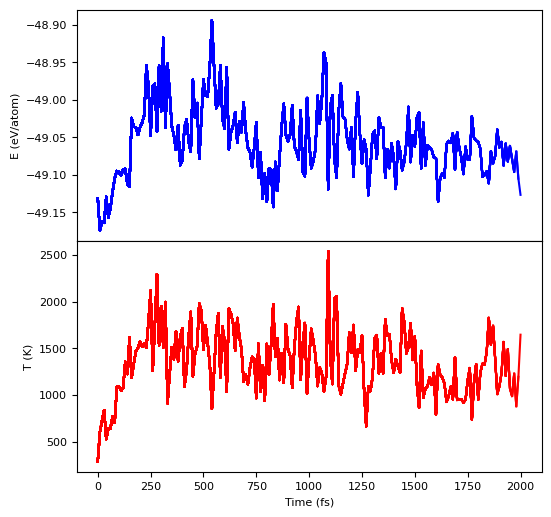

MD finished in 0.76 minutes!


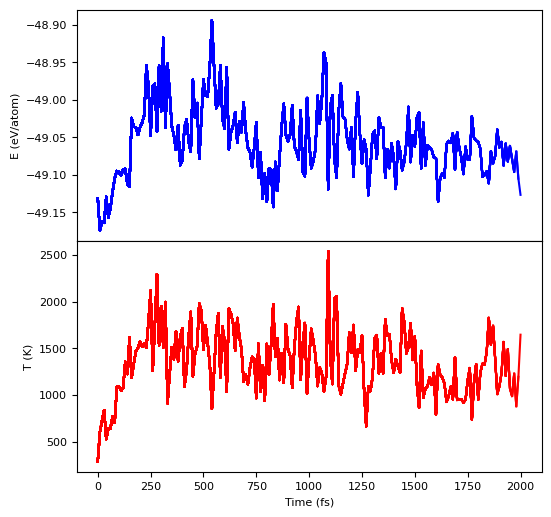

In [52]:
#let us start with a single molecule
init_conf = ea.sel_by_info_val(read('data/solvent_molecs.xyz',':'), 'Nmols', 1)[0].copy()
Path(f"moldyn/{model_name}").mkdir(parents=True, exist_ok=True)

#we can use MACE as a calculator in ASE!
from mace.calculators import MACECalculator
mace_calc = MACECalculator(model_paths=[f'MACE_models/{model_name}/{model_name}_stagetwo.model'], device=device)

simpleMD(init_conf, temp=1200, calc=mace_calc, fname=f'moldyn/{model_name}/{model_name}_md.xyz', s=10, T=2000)

Depending on the random seed for the MD, you may see different things. At first sight, the energy against time doesn't look too bad. Let's look at the trajectory.

In [53]:
from ase.io import read
from weas_widget import WeasWidget

traj = read(f'moldyn/{model_name}/{model_name}_md.xyz', ':')
viewer1 = WeasWidget()
viewer1.from_ase(traj)
viewer1.avr.model_style = 0
viewer1.avr.show_hydrogen_bonds = False
viewer1

WeasWidget(children=(<weas_widget.base_widget.BaseWidget object at 0x7e9c54294680>,))

If you go to the end of the trajectory, you should find that the bond angles are actually very strange - it looks unphsyical.

**Task for you**

<div class="alert alert-block alert-info">

Sometimes, when the model is very bad you may find the simulation exploding. Try for yourself, reduce the size of the model (e.g. number of channels) and see if a small model will generated exploding simulations.
</div>

### 1.2 Identify the problem and expand training

Something doesn't look right with the hydrogen atoms. Let's re-evaluate the first 100 steps from the trajectory on the reference XTB potential energy surface and then plot it against MACE energy.

In [54]:
from ase.io import read, write
from tqdm import tqdm
from tblite.ase import TBLite
xtb_calc = TBLite(method="GFN2-xTB",verbosity=0,max_iterations=1000)

#compute true reference XTB values
print("Evaluating MACE configurations with XTB")
traj = read(f'moldyn/{model_name}/{model_name}_md.xyz', ':')
for at in tqdm(traj[:100]):
    at.calc =  TBLite(method="GFN2-xTB",verbosity=0)
    at.info['energy_xtb'] = at.get_potential_energy()
    at.arrays['forces_xtb'] = at.get_forces()
    at.calc = None

write(f'data/{model_name}_md_100_xtb.xyz', traj[:100]) #save full result

Evaluating MACE configurations with XTB


100%|██████████| 100/100 [00:00<00:00, 301.40it/s]


Text(0, 0.5, 'Total Energy per Atom (eV)')

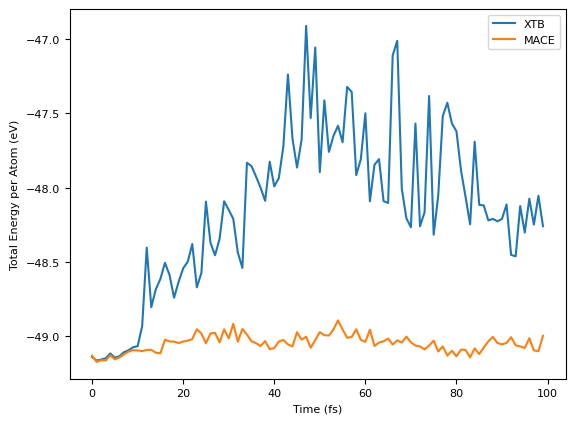

In [55]:
import numpy as np
from aseMolec import extAtoms as ea
from matplotlib import pyplot as plt

traj = read(f'data/{model_name}_md_100_xtb.xyz', ':')
plt.plot(np.arange(len(traj)), ea.get_prop(traj, 'info', 'energy_xtb', peratom=True), label='XTB')
plt.plot(np.arange(len(traj)), ea.get_prop(traj, 'info', 'energy_mace', peratom=True), label='MACE')
plt.legend()
plt.xlabel('Time (fs)')
plt.ylabel('Total Energy per Atom (eV)')

Indeed, in the second half of the trajectory, the XTB energy diverges because MACE finds unphysical configurations. With older potentials, at this point the MD would explode, but because MACE is much smoother the simulation keeps going, albeit generating the wrong dynamics. Let's take twelve of these unphysical configs, add them back to the training set and refit a new model. This is called iterative training:
![alt text](https://github.com/imagdau/Tutorials/blob/main/figures/iterative_training.png?raw=1)

In [56]:
db = read('data/solvent_xtb_train_23.xyz', ':')
db += traj[40:100:5] #add failed configs to the training set
write('data/solvent_xtb_train_35_gen1.xyz', db)

A good exercise is to try to pick the configs that have the largest error on forces and energies. Try coding it yourself.

### 1.3 Train a new MACE model and run MD again

In [57]:
import yaml
from pathlib import Path

model_name = "mace02_com1_gen1"

config={
"model": "MACE",
"num_channels": 32,
"max_L": 0,
"r_max": 4.0,
"max_ell": 2,
"name": f"{model_name}",
"model_dir": f"MACE_models/{model_name}/",
"log_dir": f"MACE_models/{model_name}/logs/",
"checkpoints_dir": f"MACE_models/{model_name}/checkpoints/",
"results_dir": f"MACE_models/{model_name}/results/",
"train_file": "data/solvent_xtb_train_35_gen1.xyz",
"valid_file": "data/solvent_xtb_valid_20.xyz",
"test_file": "data/solvent_xtb_test.xyz",
"energy_key": "energy_xtb",
"forces_key": "forces_xtb",
"batch_size": 10,
"max_num_epochs": 200,
"swa": True,
"seed": 123
}

Path("config/config-04.yml").write_text(yaml.safe_dump(config, sort_keys=False))

505

In [58]:
dev = f'device: {device}'
%store dev >>"config/config-04.yml"

Writing 'dev' (str) to file 'config/config-04.yml'.


In [59]:
train_mace("config/config-04.yml")

2026-07-26 19:00:07.081 INFO: ===========VERIFYING SETTINGS===========
2026-07-26 19:00:07.082 INFO: MACE version: 0.3.16
2026-07-26 19:00:07.111 INFO: CUDA version: 13.0, CUDA device: 0
2026-07-26 19:00:07.341 INFO: ===========LOADING INPUT DATA===========
2026-07-26 19:00:07.358 INFO: Using heads: ['Default']
2026-07-26 19:00:07.385 INFO: Using the key specifications to parse data:
2026-07-26 19:00:07.455 INFO: Default: KeySpecification(info_keys={'energy': 'energy_xtb', 'stress': 'REF_stress', 'virials': 'REF_virials', 'dipole': 'dipole', 'head': 'head', 'elec_temp': 'elec_temp', 'total_charge': 'total_charge', 'polarizability': 'polarizability', 'total_spin': 'total_spin'}, arrays_keys={'forces': 'forces_xtb', 'charges': 'REF_charges'})
2026-07-26 19:00:07.520 INFO: =============    Processing head Default     ===========
2026-07-26 19:00:07.711 INFO: Using isolated atom energies from training file
2026-07-26 19:00:07.712 INFO: Training set 1/1 [energy: 32, stress: 0, virials: 0, d

For some reason the energy error on the training set is now huge - can you work out why this is?

What does this imply about how we do iterative training?

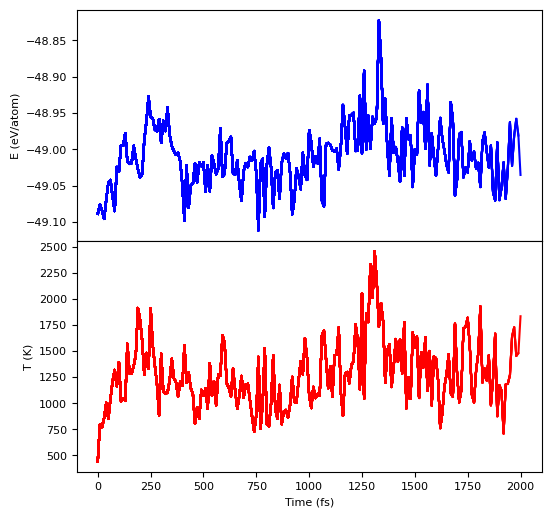

MD finished in 0.74 minutes!


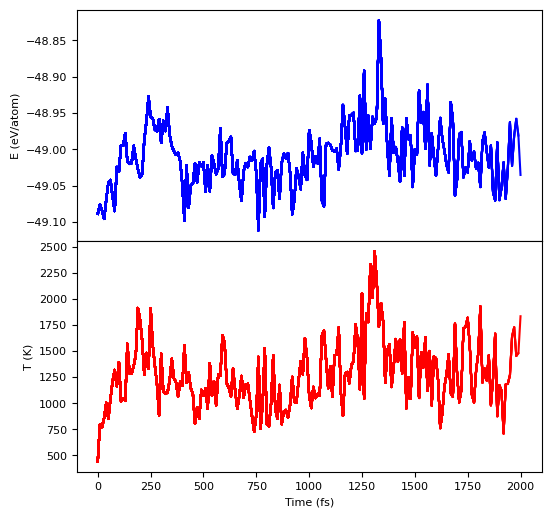

In [61]:
from pathlib import Path
from mace.calculators import MACECalculator

Path(f"moldyn/{model_name}").mkdir(parents=True, exist_ok=True)

mace_calc = MACECalculator(model_paths=[f'MACE_models/{model_name}/{model_name}_stagetwo.model'], device=device)
init_conf = ea.sel_by_info_val(read('data/solvent_molecs.xyz',':'), 'Nmols', 1)[0].copy()
simpleMD(init_conf, temp=1200, calc=mace_calc, fname=f'moldyn/{model_name}/{model_name}_md.xyz', s=10, T=2000)

In [62]:
from weas_widget import WeasWidget

traj = read(f'moldyn/{model_name}/{model_name}_md.xyz', ':')
w = WeasWidget()
w.from_ase(traj)
w.avr.model_style = 1
w.avr.show_hydrogen_bonds = True
w

WeasWidget(children=(<weas_widget.base_widget.BaseWidget object at 0x7e9c884eae70>,))

Great! The dynamics is already looking better, however it can be difficult to tell if it is really correct or not.

**Task for you**
<div class="alert alert-block alert-info">
    
- Compute the true XTB enery and check if they agree with the MACE energy predicted along the trajectory
- Compute radial distribution functions (RDFs) and compared to a ground truth RDFs
- If the MACE trajectory does not agree with the ground truth, continue the iterative process and gradually improve the potential
- For every new potential, repeat the dynamics and check against grount truth observables.
</div>

This is an arduous process, because we need to carefully investigate the trajectories and decide which configs to add back to training. If the ground truth is expensive to compute (DFT, QM) this becomes a very slow process. We could instead automate this protocol by approximating the errors (e.g. via a committee of models) on the fly and select configs which are not well predicted: this is called active learning.

## 2. Active Learning with MACE

### 2.1 Preparing a committee of models

We can **compute** errors by evaluating the reference energy and forces (in our case XTB) and computing the difference to MACE predictions. In real research applications, this can be very expensive to evaluate depending on the reference level of theory. Alternatively, we can **estimate** errors based on a committee of models. Let's train a committee of MACE models by adding some randomness to the optimization process. We can achieve this by changing the `--seed`. We already have a model, we will fit two more, on the same data:

In [63]:
import yaml
from pathlib import Path

#the committee members differ only by their random seed; com1 was trained further up
committee_names = ["mace02_com1", "mace02_com2", "mace02_com3"]
model_name = committee_names[1]

config={
"model": "MACE",
"num_channels": 32,
"max_L": 0,
"r_max": 4.0,
"name": f"{model_name}",
"model_dir": f"MACE_models/{model_name}/",
"log_dir": f"MACE_models/{model_name}/logs/",
"checkpoints_dir": f"MACE_models/{model_name}/checkpoints/",
"results_dir": f"MACE_models/{model_name}/results/",
"train_file": "data/solvent_xtb_train_23.xyz",
"valid_file": "data/solvent_xtb_valid_20.xyz",
"test_file": "data/solvent_xtb_test.xyz",
"energy_key": "energy_xtb",
"forces_key": "forces_xtb",
"batch_size": 10,
"max_num_epochs": 200,
"swa": True,
"seed": 345
}

Path("config/config-05.yml").write_text(yaml.safe_dump(config, sort_keys=False))

464

In [64]:
dev = f'device: {device}'
%store dev >>"config/config-05.yml"

Writing 'dev' (str) to file 'config/config-05.yml'.


In [65]:
import yaml
from pathlib import Path

model_name = committee_names[2]

config={
"model": "MACE",
"num_channels": 32,
"max_L": 0,
"r_max": 4.0,
"name": f"{model_name}",
"model_dir": f"MACE_models/{model_name}/",
"log_dir": f"MACE_models/{model_name}/logs/",
"checkpoints_dir": f"MACE_models/{model_name}/checkpoints/",
"results_dir": f"MACE_models/{model_name}/results/",
"train_file": "data/solvent_xtb_train_23.xyz",
"valid_file": "data/solvent_xtb_valid_20.xyz",
"test_file": "data/solvent_xtb_test.xyz",
"energy_key": "energy_xtb",
"forces_key": "forces_xtb",
"batch_size": 10,
"max_num_epochs": 200,
"swa": True,
"seed": 567
}

Path("config/config-06.yml").write_text(yaml.safe_dump(config, sort_keys=False))

464

In [66]:
dev = f'device: {device}'
%store dev >>"config/config-06.yml"

Writing 'dev' (str) to file 'config/config-06.yml'.


In [67]:
train_mace("config/config-05.yml")
train_mace("config/config-06.yml")

2026-07-26 19:03:17.695 INFO: ===========VERIFYING SETTINGS===========
2026-07-26 19:03:17.696 INFO: MACE version: 0.3.16
2026-07-26 19:03:17.697 INFO: CUDA version: 13.0, CUDA device: 0
2026-07-26 19:03:17.734 INFO: ===========LOADING INPUT DATA===========
2026-07-26 19:03:17.735 INFO: Using heads: ['Default']
2026-07-26 19:03:17.736 INFO: Using the key specifications to parse data:
2026-07-26 19:03:17.737 INFO: Default: KeySpecification(info_keys={'energy': 'energy_xtb', 'stress': 'REF_stress', 'virials': 'REF_virials', 'dipole': 'dipole', 'head': 'head', 'elec_temp': 'elec_temp', 'total_charge': 'total_charge', 'polarizability': 'polarizability', 'total_spin': 'total_spin'}, arrays_keys={'forces': 'forces_xtb', 'charges': 'REF_charges'})
2026-07-26 19:03:17.738 INFO: =============    Processing head Default     ===========
2026-07-26 19:03:17.767 INFO: Using isolated atom energies from training file
2026-07-26 19:03:17.768 INFO: Training set 1/1 [energy: 20, stress: 0, virials: 0, d

In [68]:
#remove checkpoints since they may cause errors on retraining a model with the same name but a different architecture
from pathlib import Path
for name in committee_names:
    for file in Path(f"MACE_models/{name}/checkpoints").glob("*.pt"):
        file.unlink()

Perfect, we have two new models. Let's start by testing the commitee on the first 100 frames of the first trajectory we generated. The `MACECalculator` can conveniently take a list of calculators as input and will compute separate energies from each calculator.

2026-07-26 19:04:54.882 INFO: Running committee mace with 3 models
2026-07-26 19:04:54.884 INFO: CUDA version: 13.0, CUDA device: 0
2026-07-26 19:04:54.885 INFO: Using head Default out of  ['Default']
2026-07-26 19:04:54.886 WARNING: No dtype selected, switching to float64 to match model dtype.


100%|██████████| 100/100 [00:03<00:00, 33.19it/s]


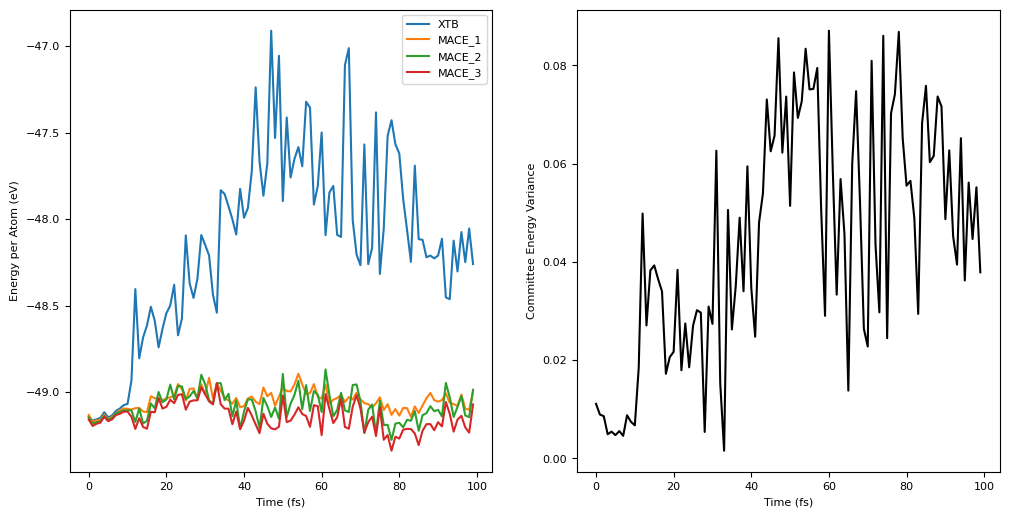

In [69]:
import numpy as np
from ase.io import read
from aseMolec import extAtoms as ea
from matplotlib import pyplot as plt
from mace.calculators import MACECalculator
from tqdm import tqdm
import warnings
warnings.filterwarnings("ignore")

model_paths = [f'MACE_models/{name}/{name}_stagetwo.model' for name in committee_names]
mace_calcs = MACECalculator(model_paths=model_paths, device=device)

traj = read(f'data/{committee_names[0]}_md_100_xtb.xyz', ':')
for at in tqdm(traj):
    at.calc = mace_calcs
    at.get_potential_energy()
    engs = at.calc.results['energy_comm']
    at.info['energy_mace_1'] = at.info.pop('energy_mace') #rename value obtained with first member of the committee
    at.info['energy_mace_2'] = engs[1]
    at.info['energy_mace_3'] = engs[2]
    at.info['variance'] = np.std(engs)
    at.info['average_mace_energy'] = np.average(engs)
    at.info['true_error'] = np.abs(at.info['average_mace_energy'] - at.info['energy_xtb'])

#Let's check the energies of the MACE committee vs XTB energy
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)

plt.plot(np.arange(len(traj)), ea.get_prop(traj, 'info', 'energy_xtb', peratom=True), label='XTB');
plt.plot(np.arange(len(traj)), ea.get_prop(traj, 'info', 'energy_mace_1', peratom=True), label='MACE_1');
plt.plot(np.arange(len(traj)), ea.get_prop(traj, 'info', 'energy_mace_2', peratom=True), label='MACE_2');
plt.plot(np.arange(len(traj)), ea.get_prop(traj, 'info', 'energy_mace_3', peratom=True), label='MACE_3');
plt.legend()
plt.xlabel('Time (fs)');
plt.ylabel('Energy per Atom (eV)');

plt.subplot(1,2,2)
plt.plot(np.arange(len(traj)), ea.get_prop(traj, 'info', 'variance', peratom=True), label='committee variance', color='black');
plt.xlabel('Time (fs)');
plt.ylabel('Committee Energy Variance');


Notice how the variance (disagreement between models) increases around the same config where the true error with respect to XTB diverges. This is good news because it indicates the variance is a good proxy for true error.

**Task for you**
<div class="alert alert-block alert-info">

- Make a correlation plot between true error and estimated error. How well does the estimation perform?
- Try a commitee of models with both different seeds and trained on different selections of data. Does it perform better?
</div>

Now we can run dynamics with a commitee of models and monitor the variance in the energy prediction. Because XTB is cheap enough we can also compare that variance with the true error. Do they correlate?

### 2.2 Running MD with the MACE committee

In [ ]:
from aseMolec import extAtoms as ea
from ase import units
from ase.md.langevin import Langevin
from ase.md.velocitydistribution import Stationary, ZeroRotation, MaxwellBoltzmannDistribution
from ase.io import read, write

import random
import numpy as np
import time
import pylab as pl
from IPython import display

from tblite.ase import TBLite
from mace.calculators import MACECalculator
from pathlib import Path

model_paths = [f'MACE_models/{name}/{name}_stagetwo.model' for name in committee_names]

xtb_calc = TBLite(method="GFN2-xTB",verbosity=0)
mace_calc = MACECalculator(model_paths=model_paths, device=device)

init_conf = ea.sel_by_info_val(read('data/solvent_molecs.xyz',':'), 'Nmols', 1)[0].copy()
init_conf.calc = mace_calc

#initialize the temperature
np.random.seed(701)
MaxwellBoltzmannDistribution(init_conf, temperature_K=300)
Stationary(init_conf)
ZeroRotation(init_conf)

dyn = Langevin(init_conf, 1*units.fs, temperature_K=1200, friction=0.1)

%matplotlib inline

time_fs = []
temperature = []
energies_1 = []
energies_2 = []
energies_3 = []
variances = []
xtb_energies = []
true_errors = []

committee_md = 'moldyn/mace02_committee/mace02_md_committee.xyz'
Path(committee_md).parent.mkdir(parents=True, exist_ok=True)
Path(committee_md).unlink(missing_ok=True) #remove previously stored trajectory with the same name
fig, ax = pl.subplots(4, 1, figsize=(8,8), sharex='all', gridspec_kw={'hspace': 0, 'wspace': 0})


def write_frame():
        at = dyn.atoms.copy()
        at.calc = xtb_calc
        xtb_energy = at.get_potential_energy()

        dyn.atoms.write(committee_md, append=True, write_results=False)
        time_fs.append(dyn.get_time()/units.fs)
        temperature.append(dyn.atoms.get_temperature())
        energies_1.append(dyn.atoms.calc.results["energy_comm"][0]/len(dyn.atoms))
        energies_2.append(dyn.atoms.calc.results["energy_comm"][1]/len(dyn.atoms))
        energies_3.append(dyn.atoms.calc.results["energy_comm"][2]/len(dyn.atoms))
        variances.append(dyn.atoms.calc.results["energy_var"]/len(dyn.atoms))
        xtb_energies.append(xtb_energy/len(dyn.atoms))
        true_errors.append(np.var([dyn.atoms.calc.results["energy"],xtb_energy])/len(dyn.atoms))

        # plot the true error
        ax[0].plot(np.array(time_fs), np.array(true_errors), color="black")
        ax[0].set_ylabel(r'$\Delta$ E (eV$^2$/atom)')
        ax[0].legend(['Error w.r.t. XTB'], loc='upper left')

        # plot committee variance
        ax[1].plot(np.array(time_fs), np.array(variances), color="y")
        ax[1].set_ylabel(r'committee variance')
        ax[1].legend(['Estimated Error (committee variances)'], loc='upper left')

        # plot the temperature of the system as subplots
        ax[2].plot(np.array(time_fs), temperature, color="r", label='Temperature')
        ax[2].set_ylabel("T (K)")

        ax[3].plot(np.array(time_fs), energies_1, color="g")
        ax[3].plot(np.array(time_fs), energies_2, color="y")
        ax[3].plot(np.array(time_fs), energies_3, color="olive")
        ax[3].plot(np.array(time_fs), xtb_energies, color="black")
        ax[3].set_ylabel("E (eV/atom)")
        ax[3].set_xlabel('Time (fs)')
        ax[3].legend(['E mace1', 'E mace2', 'E mace3', 'E xtb'], loc='upper left')

        display.clear_output(wait=True)
        display.display(fig)
        time.sleep(0.01)

dyn.attach(write_frame, interval=10)
dyn.run(500)
print("MD finished!")

NOTE: if you get the error `xtb could not evalute the config` that means the dynamics went so crazy and gave such strange configurations, that xtb refused to run! thats to be expected if the model is really bad. Copy some of the code above to have a look at the trajectory if you'd like to see this.

Closely observe the dynamics. Notice how good the committee error is as a proxy for the true error. In this case the true is cheap to compute, but in most practical applications it won't be. Therefore, we will need to rely on the committee error to identy configurations that should be added back to the training set. This is called active learning:

![alt text](https://github.com/imagdau/Tutorials/blob/main/figures/active_learning.png?raw=1)

### Active learning in practice

The way to use active learning to improve the model is as follows:
1. run dynmics, track the uncertainty.
2. if the uncertainty breaches some predeterined value, stop the simulation and peform the ground truth calculation.
3. and the new config to the dataset, and retrain
4. repeat steps 1-3 until the uncertainty never crosses the threshold

This can be done without human supervision - you can write a program which loops this process.

As an exercise at the end of the notebook, try writing an active learing loop to gradually grow the dataset and produce a good model, without ever running XTB dynamics.

## 3 Foundational Models

### 3.1 Molecular Dynamics with MACE-MP-0

Foundation models are evolving fast. MACE-MP-0 is an early model trained on >1 million DFT calcuations, and can run dynamics for the whole periodic table.

MACE provides a simple interface to load a foundational model, which we use here. Check the [documentation](https://mace-docs.readthedocs.io/en/latest/guide/foundation_models.html) for more details.

In [ ]:
from mace.calculators import mace_anicc, mace_mp, mace_off, mace_omol, mace_polar

macemp = mace_mp(model="medium-0b3",device=device)
init_conf = ea.sel_by_info_val(read('data/solvent_molecs.xyz',':'), 'Nmols', 1)[0].copy()
simpleMD(init_conf, temp=1200, calc=macemp, fname='moldyn/mace03_md.xyz', s=10, T=2000)

The dynamics looks good. It is stable with an out-of-the-box model. Let's inspect the trajectory:

In [ ]:
from weas_widget import WeasWidget

traj = read('moldyn/mace03_md.xyz', ':')
w = WeasWidget()
w.from_ase(traj)
w.avr.model_style = 1
w.avr.show_hydrogen_bonds = True
w

#### More foundation models

##### MACE_MP Second Generation

mace_mp has a second generation models that include multihead training. The two models are called mh-1 and mh-0. These models have heads corresponding to different levels of theory. More details about architecture and training in https://arxiv.org/abs/2510.25380.
The current heads are:
  - matpes_r2scan
  - mp_pbe_refit_add
  - spice_wB97M
  - oc20_usemppbe
  - omol
  - omat_pbe

to load such a model:


In [ ]:
from mace.calculators import mace_mp
mace_mp_mh_1 = mace_mp(model="mh-1",device=device,head="omat_pbe")


Then you can use this calcualtor as usually.

You can download the model and more manually from https://github.com/ACEsuit/mace-foundations/releases/tag/mace_mh_1

##### Polarisable models

MACE provides a family of polarisable models that include long range electrostatics. They are called generic MACE-POLAR-1. For more information on architecture and training data you can browse https://arxiv.org/abs/2602.19411. There are three models available, MACE-Polar-1-s, MACE-Polar-1-m and MACE-Polar-1-l. to load them and use them you can use the following skeleton code:

In [ ]:
from mace.calculators import mace_polar
from ase.build import molecule

atoms = molecule("H2O")
calc = mace_polar(
    model="polar-1-m", # or "polar-1-l" or "polar-1-s"
    device="cuda",           # or "cuda"
    default_dtype="float64" # use float32 for faster MD
)

atoms.info["charge"] = 0
atoms.info["spin"] = 1
atoms.info["external_field"] = [0.0, 0.0, 0.0]
atoms.calc = calc

energy = atoms.get_potential_energy()
forces = atoms.get_forces()
stress = atoms.get_stress()

not this block
```python
atoms.info["charge"] = 0
atoms.info["spin"] = 1
atoms.info["external_field"] = [0.0, 0.0, 0.0]
```

you can specify charge, spin and electric field if you want, if you let them out will use some default values.

MACE Polar can compute other properties beyond energy, forces and stresses like charges, dipoles, and charge densities.
To access them you need to read them from the calculator results dictionary after it was populated, eg by calling get_potential_energy()



In [ ]:
# total molecular dipole vector
μ = calc.results["dipole"]

# full atom-centered multipole coefficients
ρ = calc.results["density_coefficients"]

# spin-up / spin-down multipole coefficients
ρ_spin = calc.results["spin_charge_density"]

# atom-resolved monopole charges only
q = calc.results["charges"]

you can download the model and more manually from https://github.com/ACEsuit/mace-foundations/releases/tag/mace_polar_1

**Note** mace polar needs, at the moment, an extra package installed in addition to mace, from this repository https://github.com/WillBaldwin0/graph_electrostatics.git


Other foundation model from MACE_MP family that can be usefuls is mace-matpes-r2scan-0, trained on MATPES dataset and using R2SCAN functional... there is also a PBE flavour, called mace-matpes-pbe-0

If you want to use a MACE model trained against OMOL25 dataset, you can use omol head from MH-1 models or from mace_omol with  model=extra_large

**tip** Best way to find the latest shortcuts for various foundation models that can be downloaded automatically is by inspecting this file from MACE repository

https://github.com/ACEsuit/mace/blob/667eee4e58d23a38ff5a75122109ec2025809649/mace/calculators/foundations_models.py#L50



### 3.2 Compare to XTB

Let's compute the radial distribution functions of the trajectory and compare them to XTB. Remember MACE-MP was trained on PBE level of theory so we don't necessarily expect them to match:

In [ ]:
from matplotlib import pyplot as plt
from aseMolec import anaAtoms as aa

tag = 'CC_intra' #choose one of 'HH_intra', 'HC_intra', 'HO_intra', 'CC_intra', 'CO_intra', 'OO_intra'

for f in ['xtb_md', 'mace03_md']:
    traj = read('moldyn/'+f+'.xyz', '50:') #ignore first 50 frames
    for at in traj:
        at.pbc = True #create a fake box for rdf compatibility
        at.cell = [100,100,100]
    rdf = aa.compute_rdfs_traj_avg(traj, rmax=3, nbins=200) #aseMolec provides functionality to compute RDFs
    plt.plot(rdf[1], rdf[0][tag], '.-', label=f, alpha=0.7, linewidth=3)

plt.legend();
plt.yticks([]);
plt.xlabel(r'R ($\rm \AA$)');
plt.ylabel('RDF '+tag);

RDF results look surprisingly well with out-of-the-box MACE-MP-0.

**Task for you**
<div class="alert alert-block alert-info">

Recompute the XTB energy on the MACE-MP-0 trajectory, how does it compare?
</div>

Depending on your application, the PBE reference using in MACE-MP-0 may not be appropriate, however it is already better than XTB. XTB was chosen here to minimize computational cost, so we can check the model's true error very easily.

In practice, you might want to run dynamics of this small molecule at a much higher level of accuracy like CCSD(T) (often considered the 'gold standard' of Chemistry). In that case, you would want to finetune MACE-MP-0 (or another foundational model) onto a small amount of very expensive couple cluster data.

### 3.3 Fine tune MACE-MP to XTB

As described in the previous section, MACE-MP-0 offers qualitatively good performance across a wide range of chemistries and materials at the PBE+U level of theory.
However, for specific applications, it may be beneficial to fine-tune the model to improve its accuracy.
The fine-tuning process involves training a pre-trained model on a new dataset, called the fine-tuning dataset, which contains a limited amount of data that are only relevant to the specific application. Check the [documentation](https://mace-docs.readthedocs.io/en/latest/guide/finetuning.html) for more details.

There are currently three main strategies used for fine-tuninng foundational MACE models:
1. ***standard or naive*** approach: restarts training using the parameters of the pretrained model, can lead to catastrophic forgetting
2. ***[low-rank adaptation](https://mace-docs.readthedocs.io/en/latest/guide/lora_finetuning.html)*** approach: the original parameters are updated, but only within a low-dimensional subspace. For example, instead of independently retraining all 1000 $\times$ 1000 parameters in a weight matrix W, the update is constrained by a low-rank factorisation such as W=AB, where A and B have reduced dimensions (e.g. 1000 $\times$ 4)
3. ***[multi-head](https://mace-docs.readthedocs.io/en/latest/guide/multihead_finetuning.html)*** approach: simultaneously retrains the model on both the target dataset and a “replay” dataset from the original pretraining data which keeps the model grounded and minimizes forgetting.

Let us explore the ***standard*** aproach by setting `multiheads_finetuning: False` in the config. You will try for yourself to train another model with the ***multi-head*** approach and compare performances. Remember to change the name both in the config and when running MD.

In [ ]:
import yaml
from pathlib import Path

model_name = "finetuned_standard_MACE"

config={
"model": "MACE",
"stress_weight": 0.0,
"forces_weight": 10.0,
"energy_weight": 1.0,
"foundation_model": "medium-omat-0",
"multiheads_finetuning": False,
"name": f"{model_name}",
"model_dir": f"MACE_models/{model_name}/",
"log_dir": f"MACE_models/{model_name}/logs/",
"checkpoints_dir": f"MACE_models/{model_name}/checkpoints/",
"results_dir": f"MACE_models/{model_name}/results/",
"pt_train_file": "mp",
"heads": {
    "xtb": {
        "train_file": "data/solvent_xtb_train_23.xyz",
        "valid_file": "data/solvent_xtb_valid_20.xyz",
        "test_file": "data/solvent_xtb_test.xyz",
        },
    },
"energy_key": "energy_xtb",
"forces_key": "forces_xtb",
"batch_size": 10,
"max_num_epochs": 100,
"swa": False,
"seed": 345
}

Path("config/config-07.yml").write_text(yaml.safe_dump(config, sort_keys=False))

In [ ]:
dev = f'device: {device}'
%store dev >>"config/config-07.yml"

In [ ]:
train_mace("config/config-07.yml")

In [ ]:
from IPython.display import Image, display
display(Image(f"MACE_models/{model_name}/results/{model_name}_run-345_train_xtb_stage_one.png"))

Compare the final accuracy to the models trained from scratch. You should see that the errors are much better when doing finetuning.

In [ ]:
from IPython import display

Path(f"moldyn/{model_name}").mkdir(parents=True, exist_ok=True)

mace_calc = MACECalculator(model_paths=[f'MACE_models/{model_name}/{model_name}_compiled.model'], device=device, dtype="float32")

init_conf = ea.sel_by_info_val(read('data/solvent_molecs.xyz',':'), 'Nmols', 1)[0].copy()
simpleMD(init_conf, temp=1200, calc=mace_calc, fname=f'moldyn/{model_name}/{model_name}_md.xyz', s=10, T=2000)

In [ ]:
from matplotlib import pyplot as plt
from aseMolec import anaAtoms as aa

tag = 'CC_intra' # 'OO_intra' #choose one of 'HH_intra', 'HC_intra', 'HO_intra', 'CC_intra', 'CO_intra', 'OO_intra'

for label, fname in [('xtb_md', 'moldyn/xtb_md.xyz'),
                     (model_name, f'moldyn/{model_name}/{model_name}_md.xyz')]:
    traj = read(fname, '50:') #ignore first 50 frames
    for at in traj:
        at.pbc = True #create a fake box for rdf compatibility
        at.cell = [100,100,100]
    rdf = aa.compute_rdfs_traj_avg(traj, rmax=3, nbins=200)
    plt.plot(rdf[1], rdf[0][tag], '.-', label=label, alpha=0.7, linewidth=3)

plt.legend();
plt.yticks([]);
plt.xlabel(r'R ($\rm \AA$)');
plt.ylabel('RDF '+tag);

In [ ]:
from weas_widget import WeasWidget

traj = read(f'moldyn/{model_name}/{model_name}_md.xyz', ':')
w = WeasWidget()
w.from_ase(traj)
w.avr.model_style = 1
w.avr.show_hydrogen_bonds = True
w

What are the results - does it work?

**Tasks for you**
<div class="alert alert-block alert-info">

- comparing more than one of the rdfs
- compare XTB energy. does the fine-tuned model perform better than the model trained from scratch?
- retry with the multi-head fine-tuning strategy, how does that perform?
- notice the fine-tuned model has different hyperparameters inhreted from the foundational model, is this a fair comparison? Consider training a model from scracth with the same parameters.
</div>

Below is an example config file for multi-head fine-tuning. Experiment with different parameters and check if this strategy performs better.

In [ ]:
import yaml
from pathlib import Path

model_name = "finetuned_multihead_MACE"

config={
"model": "MACE",
"stress_weight": 0.0,
"forces_weight": 10.0,
"energy_weight": 1.0,
"foundation_model": "medium-omat-0",
"multiheads_finetuning": True,
"skip_evaluate_heads": False,
"name": f"{model_name}",
"model_dir": f"MACE_models/{model_name}/",
"log_dir": f"MACE_models/{model_name}/logs/",
"checkpoints_dir": f"MACE_models/{model_name}/checkpoints/",
"results_dir": f"MACE_models/{model_name}/results/",
"pt_train_file": "mp",
"heads": {
    "xtb": {
        "train_file": "data/solvent_xtb_train_23.xyz",
        "valid_file": "data/solvent_xtb_valid_20.xyz",
        "test_file": "data/solvent_xtb_test.xyz",
        },
    },
"energy_key": "energy_xtb",
"forces_key": "forces_xtb",
"batch_size": 10,
"lr": 0.0001,
"scaling": "rms_forces_scaling",
"force_mh_ft_lr": True,
"ema_decay": 0.99999,
"max_num_epochs": 5,
"num_samples_pt": 10000,
"swa": False,
"enable_cueq": True,
"seed": 345
}

Path("config/config-08.yml").write_text(yaml.safe_dump(config, sort_keys=False))

In [ ]:
dev = f'device: {device}'
%store dev >>"config/config-08.yml"

In [ ]:
train_mace("config/config-08.yml")